# UFC Prediction Pipeline v3 — Orchestration Notebook

This notebook imports the modular engine from `UFCPREDv3/` and calls
`run_pipeline.main()` which executes every phase in order.

All logic lives in `.py` files under `src/`; this notebook is a thin
interface for interactive exploration.

Pipeline module loaded. Call main([]) to execute.

PHASE 1: Loading and cleaning raw data
  Raw files loaded: fights=8701, stats=40998, events=774, tott=4496

PHASE 2: Building master DataFrame (join + outcome)

PHASE 3: Feature engineering

  3a: Parsing stats table...
      fighter_fights shape: (17358, 27)

  3b: Parsing physicals & metadata...

  3c: Building chronological table...
      chrono shape: (17450, 42), date range: 1994-03-11 00:00:00 → 2026-05-16 00:00:00

  3d: Running chronological feature engine...
Processing 8701 fights chronologically...
  1000/8701
  2000/8701
  3000/8701
  4000/8701
  5000/8701
  6000/8701
  7000/8701
  8000/8701
Done processing fights.
      master_df shape with features: (8701, 91), feature cols: 86

  3e: Adding pairwise matchup features...
Pairwise features added: 23
      master_df shape after pairwise: (8701, 114)

      Exported master_df ((8701, 114)) to /private/tmp/ufcPrediction/UFCPREDv3/outputs/data/ufc_master_features.csv

PHASE 4: M

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Plot saved: XGBoost — Evaluation Diagnostics — Fig1


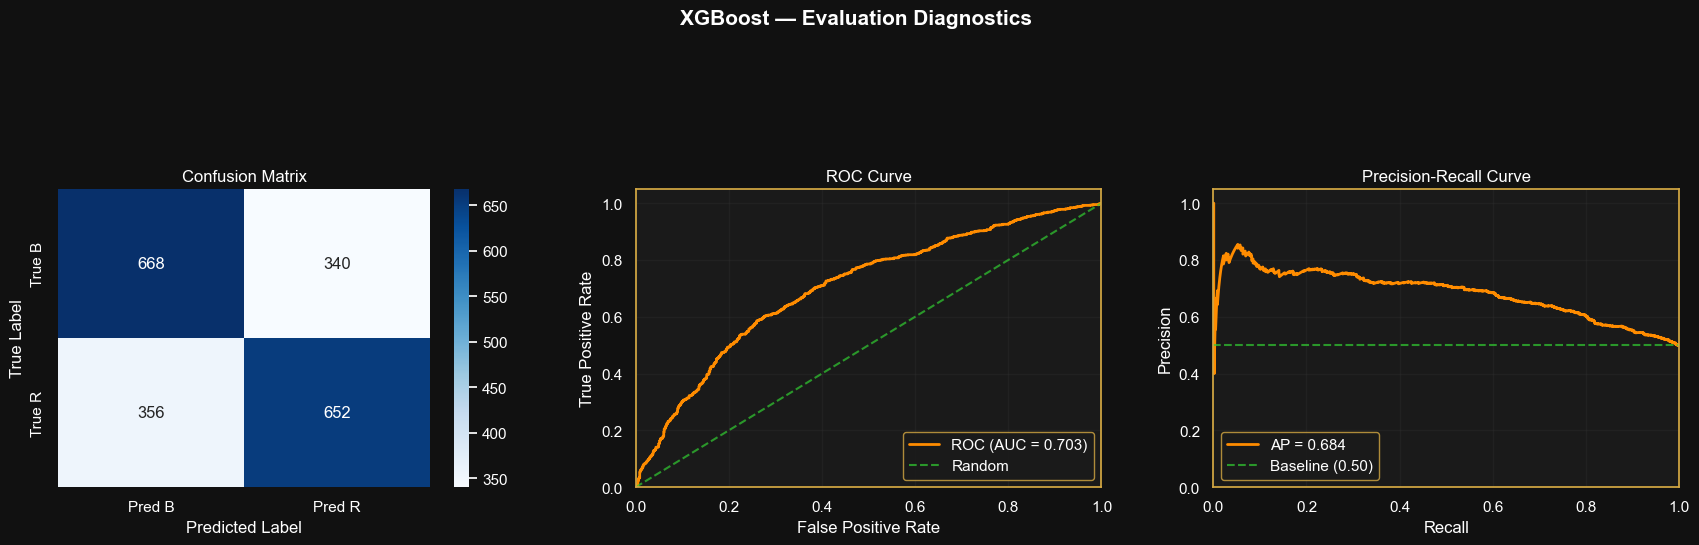

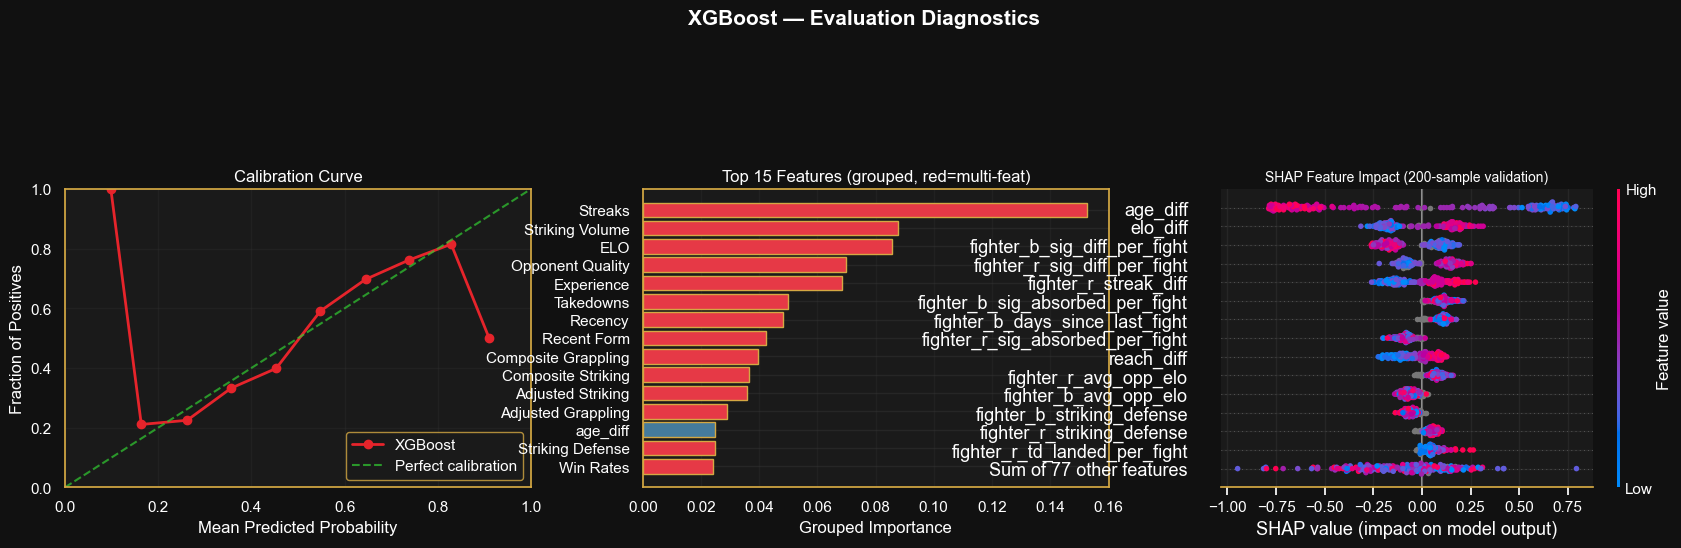

  Plot saved: XGBoost — Evaluation Diagnostics — Fig2
  Evaluation dashboard rendered ().

  4f: Post-2005 subset...
  2005+ Train: 14218, Val: 2016
  XGBoost best iteration: 154, best logloss: 0.6330

                           Model Comparison                           
Model                Accuracy   AUC-ROC    Prec(R)    Recall(R)  F1(R)     
-------------------- ---------- ---------- ---------- ---------- ----------
XGBoost (2005+)      0.6607     0.7036     0.6630     0.6538     0.6583    
Random Forest (2005+) 0.6582     0.7024     0.6593     0.6548     0.6570    
Logistic Reg (2005+) 0.6468     0.6956     0.6474     0.6448     0.6461    

  Plot saved: XGBoost — Evaluation Diagnostics (Post 2005) — Fig1


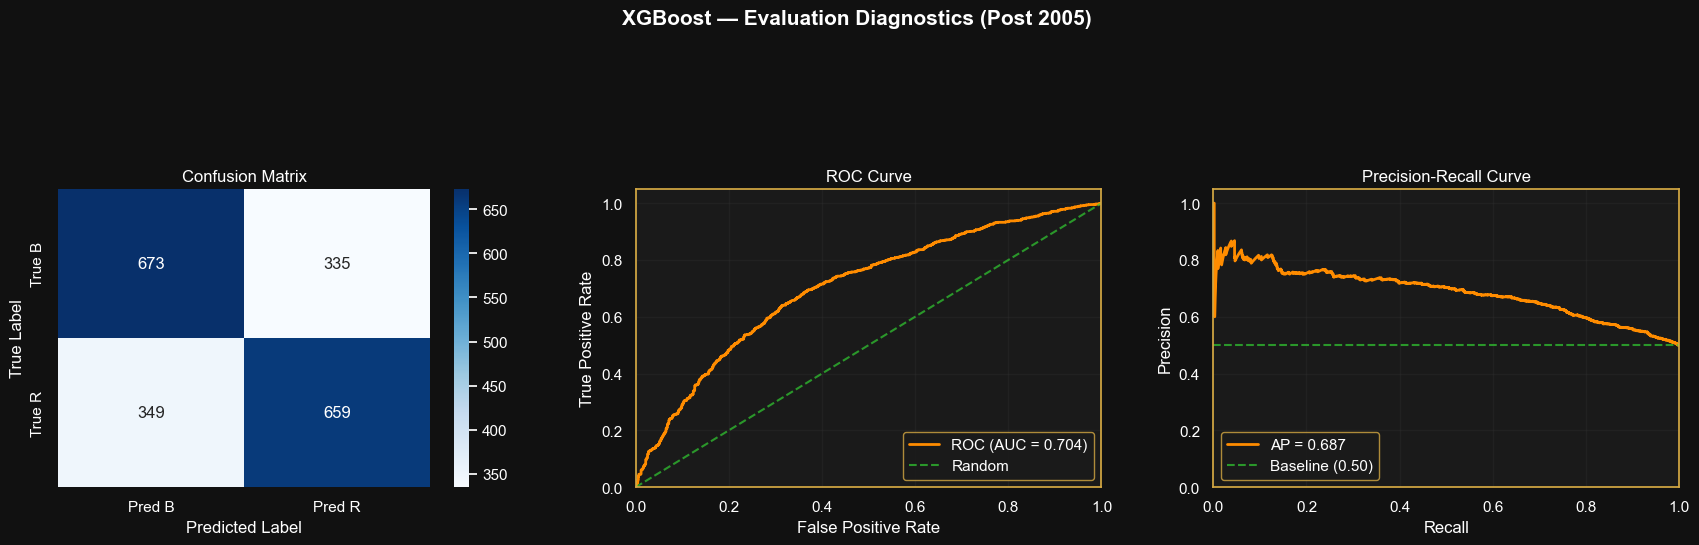

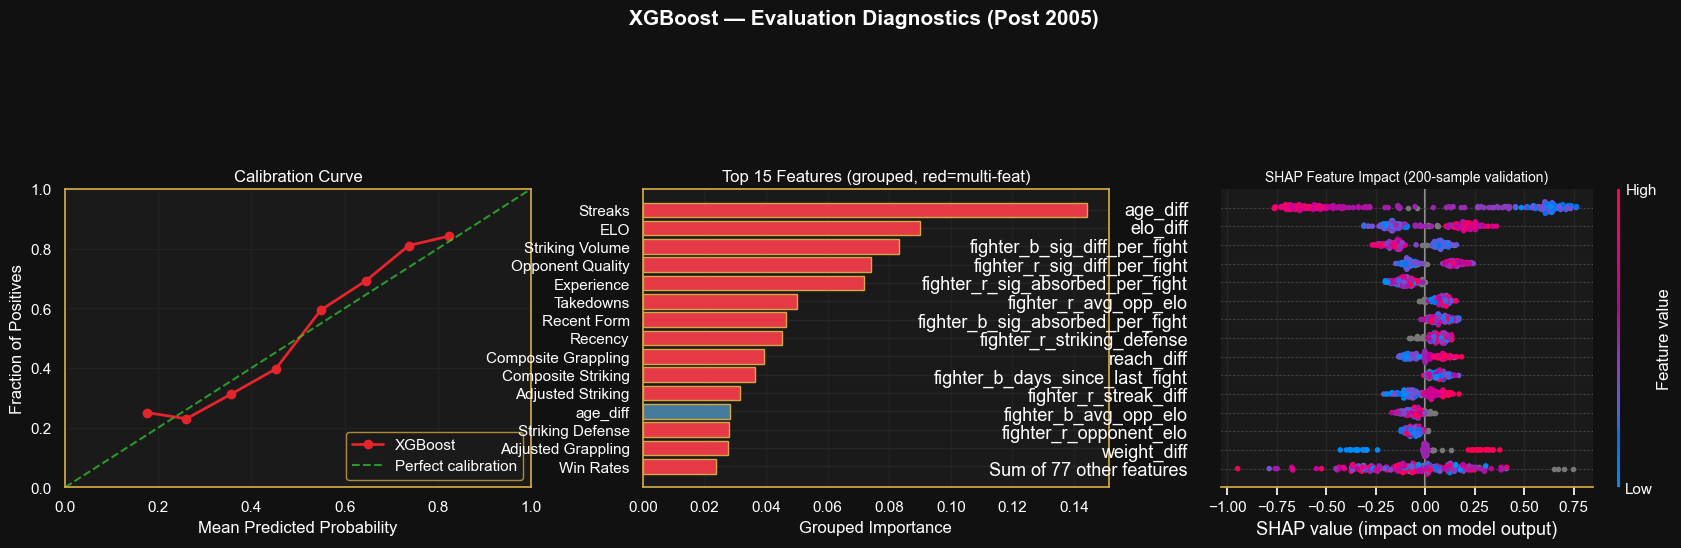

  Plot saved: XGBoost — Evaluation Diagnostics (Post 2005) — Fig2
  Evaluation dashboard rendered ( (Post 2005)).
  ELO baseline (2005+ val): 0.5446

                   Full Dataset vs 2005+ Comparison                   
Model                Acc(F)   AUC(F)   Acc(05+) AUC(05+)
-------------------- -------- -------- -------- --------
XGBoost              0.6548   0.7033   0.6607   0.7036  
Random Forest        0.6538   0.6994   0.6582   0.7024  
Logistic Reg         0.6448   0.6926   0.6468   0.6956  
ELO                  0.5446            0.5446  

  Model comparison plots saved.

  4g: Time-series cross-validation (expanding window, XGBoost)...
  Fold 1: cutoff=2010-07-03, train=2772, val=14322
  XGBoost best iteration: 13, best logloss: 0.6822
  Fold 2: cutoff=2015-03-21, train=6192, val=10902
  XGBoost best iteration: 98, best logloss: 0.6609
  Fold 3: cutoff=2019-02-17, train=9818, val=7276
  XGBoost best iteration: 161, best logloss: 0.6486
  Fold 4: cutoff=2022-09-17, train=13388

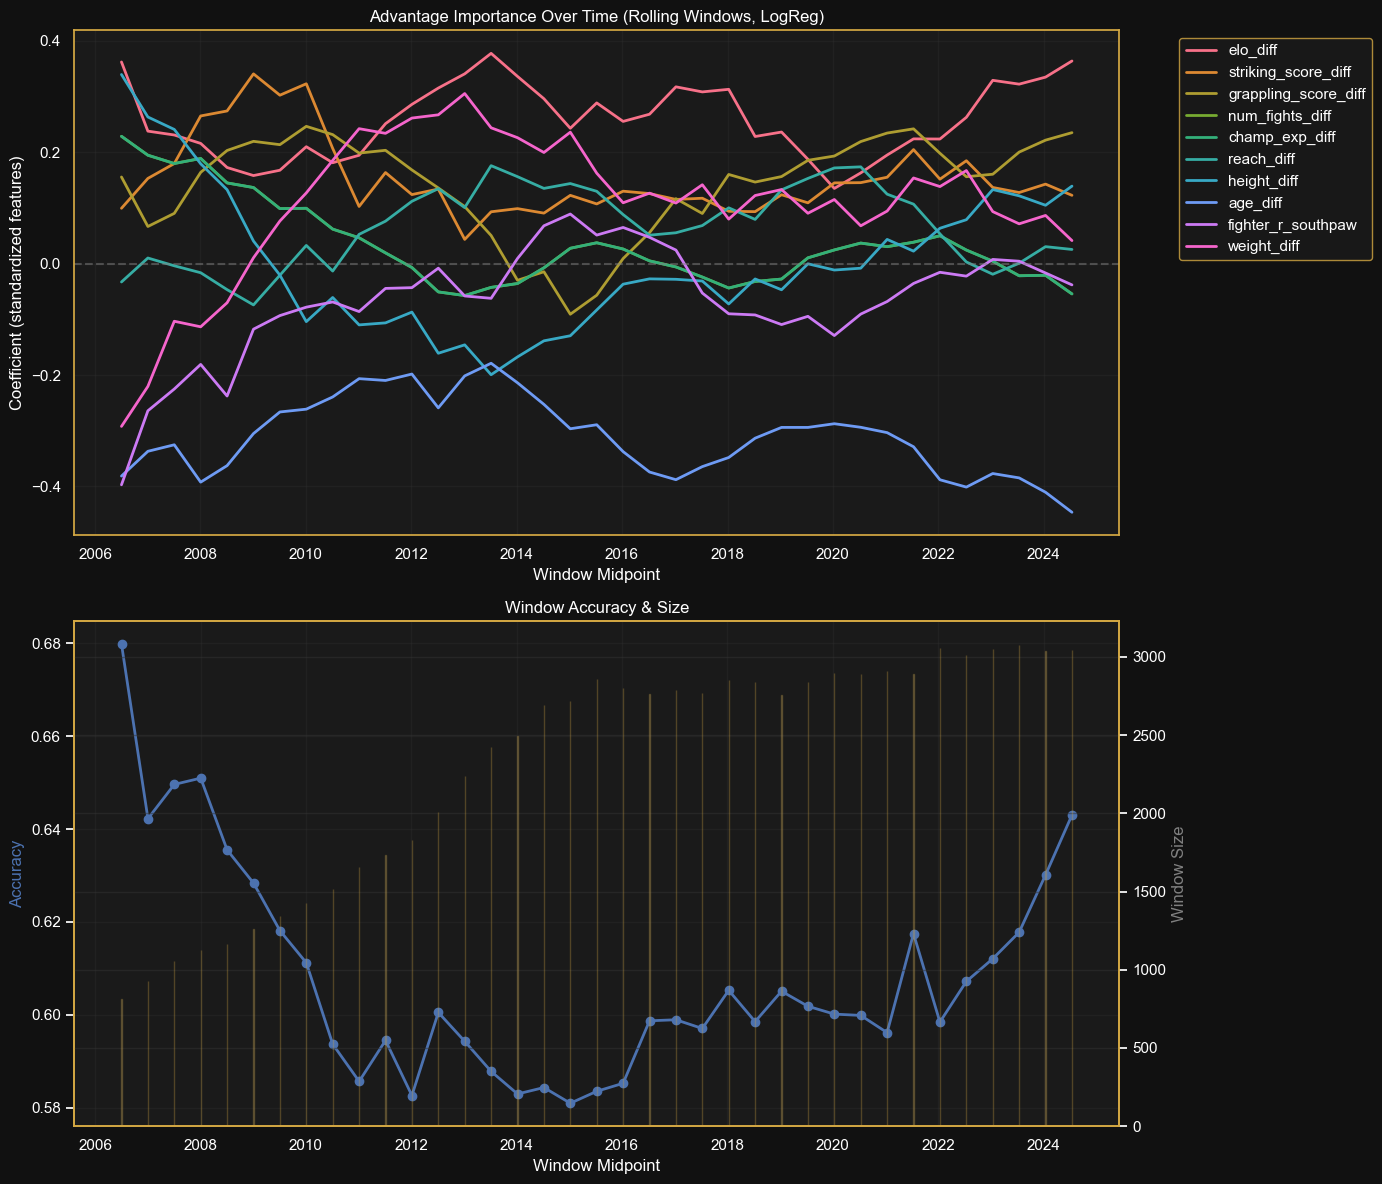


Pipeline complete.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath('..'), '..'))
from run_pipeline import main

# Run full pipeline (set flags below to skip parts)
# main()

# Options:
# main(['--skip-features'])       # Load pre-computed CSV instead of re-running feature eng
# main(['--no-cv'])                # Skip time-series cross-validation
# main(['--no-diagnostics'])       # Skip rolling-window meta analysis
print("Pipeline module loaded. Call main([]) to execute.")


main([])


---
### Quick start
```python
main(['--no-cv', '--no-diagnostics'])
```
runs data loading → feature engineering → XGBoost/RF/LR → evaluation dashboard.

> Note: pass `[]` to `main()` from notebooks to avoid argparse parsing Jupyter's kernel args.